Titanic data loaded. Shape: (891, 12)
First 5 rows:
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4 

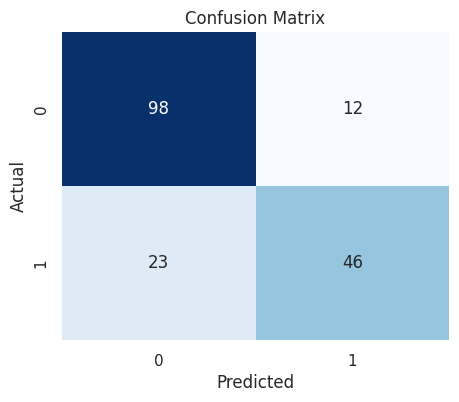

Predicted Survival: No


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [2]:
# PART A

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set()

# Step 1: Load data
df = pd.read_csv('/content/Titanic.csv')  # Assume downloaded as train.csv
print("Titanic data loaded. Shape:", df.shape)
print("First 5 rows:\n", df.head())
print(df.info())  # Check for missing values
print(df.describe())  # Summary statistics

# Step 2: Data Preparation
# Drop irrelevant columns
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'boat', 'body', 'home.dest']
for c in drop_cols:
    if c in df.columns:
        df = df.drop(columns=c)

# Handle missing values: Fill age with median, embark with mode
if 'Age' in df.columns:
    df['Age'] = df['Age'].fillna(df['Age'].median())
if 'Embarked' in df.columns:
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode().iloc[0])
if 'Fare' in df.columns:
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# Encode categorical variables
le_sex = None
le_emb = None
if 'Sex' in df.columns:
    le_sex = LabelEncoder()
    df['Sex'] = le_sex.fit_transform(df['Sex'].astype(str)) # Male=1, Female=0
if 'Embarked' in df.columns:
    le_emb = LabelEncoder()
    df['Embarked'] = le_emb.fit_transform(df['Embarked'].astype(str))

# Features and target
if 'Survived' not in df.columns:
    if 'survived' in df.columns:
        df.rename(columns={'survived': 'Survived'}, inplace=True)
    else:
        raise KeyError("Target column 'Survived' not found in Titanic dataset.")

candidate_features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
features = [c for c in candidate_features if c in df.columns]
if len(features) == 0:
    raise ValueError("No standard features found in Titanic dataset. Check column names.")

X = df[features].copy()
y = df['Survived'].astype(int)

# Split data (80% train, 20% test)
strat = y if y.nunique() > 1 else None
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=strat)

# Step 3: Modeling
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Step 4: Evaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print("Confusion Matrix:\n", conf_matrix)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Visualize Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Example Prediction
new_passenger = np.array([[3, 1, 25, 0, 0, 7.25, 2]])  # Pclass=3, Sex=1(M), Age=25, SibSp=0, Parch=0, Fare=7.25, Embarked=2(S)
prediction = model.predict(new_passenger)
print(f"Predicted Survival: {'Yes' if prediction[0] == 1 else 'No'}")
